<a href="https://colab.research.google.com/github/12370043/keiichiro/blob/main/260109_%E7%A9%BA%E6%B0%97%E6%B8%85%E6%B5%84%E6%A9%9F%E4%BD%8D%E7%BD%AE%E3%81%AE%E6%AF%94%E8%BC%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Candidates (feasible): 53 / 121
[  1/53] (x,y)=(0.40,0.40)  Cmax(0-3600)=2.998e-04@598.66s  Cmax(0-6)=3.892e-16@6.00s
[  2/53] (x,y)=(0.40,0.80)  Cmax(0-3600)=4.330e-04@539.63s  Cmax(0-6)=1.195e-15@6.00s
[  3/53] (x,y)=(0.40,1.20)  Cmax(0-3600)=5.667e-04@418.32s  Cmax(0-6)=1.075e-14@6.00s
[  4/53] (x,y)=(0.40,1.60)  Cmax(0-3600)=1.206e-04@381.05s  Cmax(0-6)=1.065e-14@6.00s
[  5/53] (x,y)=(0.40,2.00)  Cmax(0-3600)=3.047e-05@415.33s  Cmax(0-6)=2.621e-15@6.00s
[  6/53] (x,y)=(0.40,2.40)  Cmax(0-3600)=9.351e-05@693.36s  Cmax(0-6)=4.116e-16@6.00s
[  7/53] (x,y)=(0.40,2.80)  Cmax(0-3600)=1.829e-04@423.12s  Cmax(0-6)=3.864e-16@6.00s
[  8/53] (x,y)=(0.40,3.20)  Cmax(0-3600)=2.646e-04@506.99s  Cmax(0-6)=3.866e-16@6.00s
[  9/53] (x,y)=(0.40,3.60)  Cmax(0-3600)=2.865e-04@586.37s  Cmax(0-6)=3.867e-16@6.00s
[ 10/53] (x,y)=(0.80,0.40)  Cmax(0-3600)=3.203e-04@599.93s  Cmax(0-6)=4.057e-16@6.00s
[ 11/53] (x,y)=(0.80,2.40)  Cmax(0-3600)=7.010e-05@582.66s  Cmax(0-6)=5.335e-16@6.00s
[ 12/53] (x,y)=(0.80,2

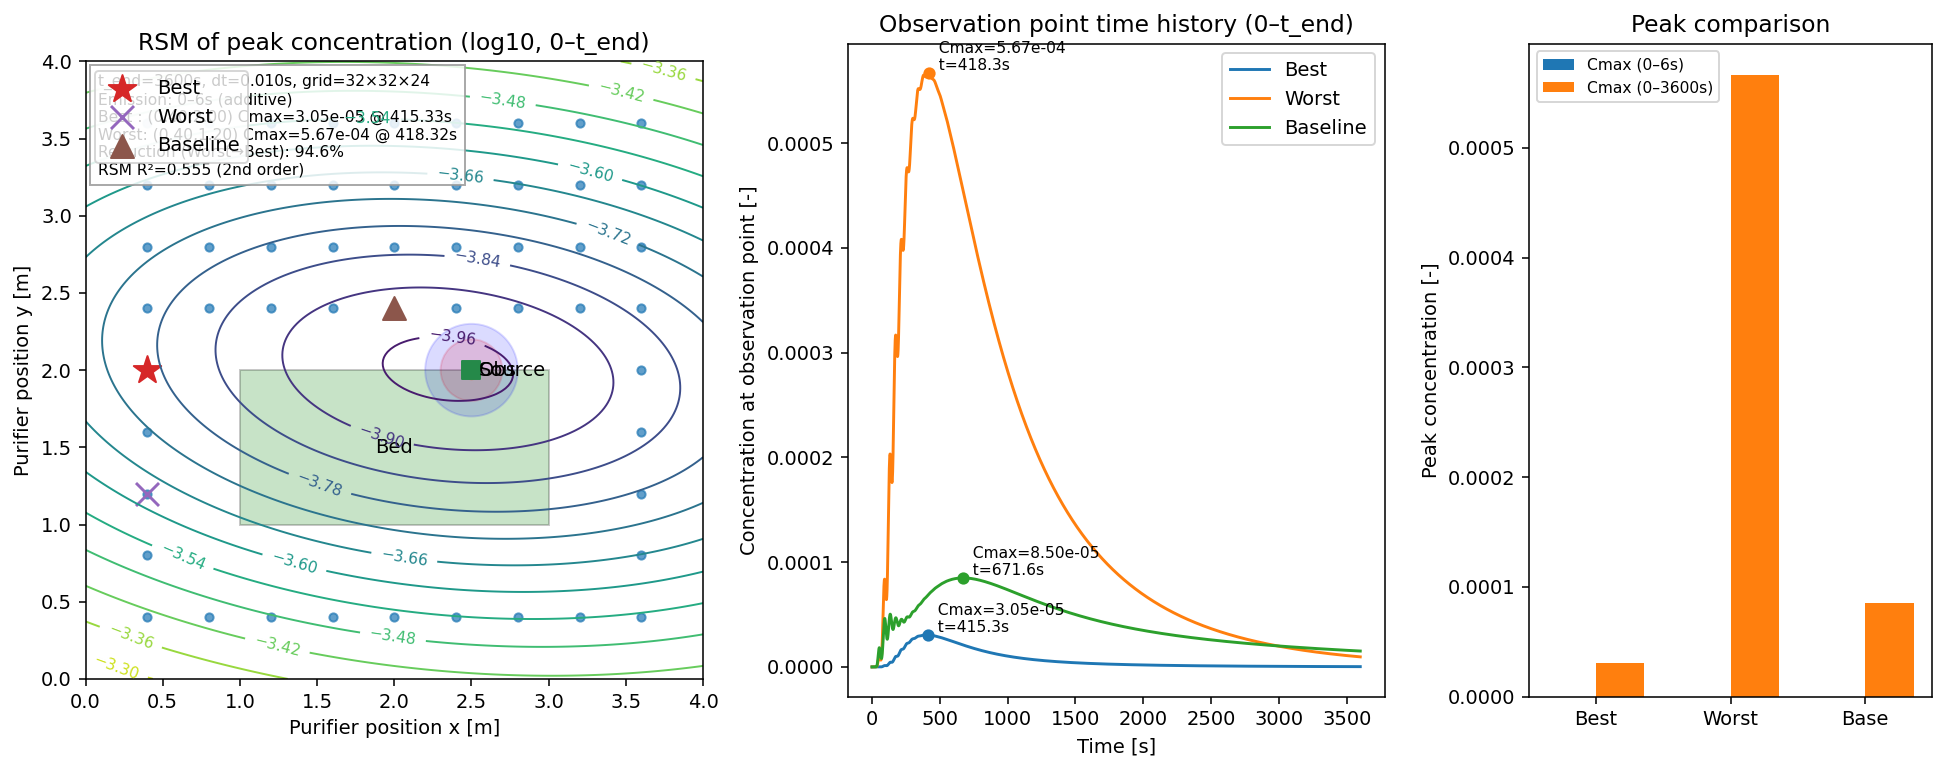


Saved:
 - opt60s_research_integrated.png
 - opt60s_research_integrated.pdf
 - opt60s_research_sweep_results.csv
 - opt60s_research_best_timeseries.csv / worst / baseline

Key numbers:
Best  xy=(0.40,2.00)  Cmax(0-3600)=3.047e-05  t_peak=415.33s
Worst xy=(0.40,1.20) Cmax(0-3600)=5.667e-04  t_peak=418.32s
Base  xy=(2.00,2.40)  Cmax(0-3600)=8.498e-05  t_peak=671.65s
Reduction (Worst→Best): 94.62%


In [ ]:
#4×4全域スイープ（ベッド非重複制約）
#配置ごとに「擬似流れ場」を再計算（簡略：背景流 + ファン体積力 + 投影で近似的に∇·U≈0）
#濃度輸送：移流(一次風上) + 拡散 + 発生源(加算, emit_t_endまで) + 清浄(吸込み領域で一次反応除去)
#観測点の濃度時系列を保存（Best/Worst/Baseline）
#指標：Cmax, t_peak, 0–6sピーク, 0–60sピーク, 抑制率
#応答曲面（2次RSM）等高線 + 時系列 + 指標棒グラフ

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# ----------------------------
# 1) 入力（ここだけ主に編集）
# ----------------------------
ROOM = {"Lx": 4.0, "Ly": 4.0, "Lz": 3.0}

# 解析・評価時間
TIME = {
    "dt": 0.01,        # tを現実的に（0.002だと60sで3万step → 全配置スイープが過重）
    "t_end": 3600.0,     # ピーク判定のため窓を延長
    "save_every": 1,   # 1なら全点保存（dt=0.01でも6001点程度）
}

# 発生源（放出は加算、emit_t_endで停止）
SOURCE = {
    "pos": (2.5, 2.0, 0.3),
    "radius": 0.20,
    "emit_rate": 1.0,     # [arb]/s  （モデルスケールは相対比較用）
    "emit_t_end": 6.0,    # 6秒で放出停止 → その後の減衰/再上昇を評価可能
}

# 観測点
OBS = {
    "pos": (2.5, 2.0, 1.5),
    "breath_R": 0.30,
}

# ベッド（障害物）
BED = {
    "x0": 1.0, "x1": 3.0,
    "y0": 1.0, "y1": 2.0,
    "z1": 0.8,
}

# 清浄機（配置は (px,py) をスイープ）
PURIFIER = {
    "footprint_R": 0.30,    # 非重複制約用
    "z_center": 0.8,
    "out_dx": 0.30,
    "CADR_like": 1.5,       # 清浄強度（一次反応除去係数に変換）
    "sink_sigma": 0.25,     # 吸込み領域ガウス幅
}

# 流れ場（簡略モデル）
FLOW = {
    "U_in": 0.10,           # 背景一様流 [m/s]（+x）
    "fan_strength": 2.0,    # ファン体積力係数（相対比較用）
    "nu_smooth": 5e-3,      # 平滑化（擬似粘性）
    "n_iter": 60,           # 速度場の反復回数（増やすほど滑らかだが重い）
    "proj_iter": 60,        # 投影（圧力Poisson）反復回数（∇·Uを抑える）
}

# 物質輸送
TRANS = {
    "D": 5e-4,             # 拡散係数
    "ACH": 0.0,            # 換気回数 [1/h]。0なら換気減衰なし。例: 6.0 など
}

# スイープ密度
NGRID = 11   # 11×11=121点（feasibleのみ実行）
BASELINE_XY = (2.0, 2.4)

OUT_PREFIX = "opt60s_research"

# ----------------------------
# 2) 格子生成（計算負荷を抑えつつ3Dは維持）
# ----------------------------
Lx, Ly, Lz = ROOM["Lx"], ROOM["Ly"], ROOM["Lz"]
Nx, Ny, Nz = 32, 32, 24  # ✅ スイープ用に現実的な格子数（必要なら増やす）
x = np.linspace(0.0, Lx, Nx)
y = np.linspace(0.0, Ly, Ny)
z = np.linspace(0.0, Lz, Nz)
dx, dy, dz = x[1]-x[0], y[1]-y[0], z[1]-z[0]

Xc, Yc, Zc = np.meshgrid(x, y, z, indexing="ij")

solid = (
    (Xc >= BED["x0"]) & (Xc <= BED["x1"]) &
    (Yc >= BED["y0"]) & (Yc <= BED["y1"]) &
    (Zc <= BED["z1"])
)

# 観測点 index
obsx, obsy, obsz = OBS["pos"]
iox = int(np.argmin(np.abs(x - obsx)))
ioy = int(np.argmin(np.abs(y - obsy)))
ioz = int(np.argmin(np.abs(z - obsz)))

# 発生源 mask
sx, sy, sz = SOURCE["pos"]
src_mask = ((Xc - sx)**2 + (Yc - sy)**2 + (Zc - sz)**2) <= (SOURCE["radius"]**2)

# 時間
dt = float(TIME["dt"])
t_end = float(TIME["t_end"])
nsteps = int(np.round(t_end / dt))
save_every = max(1, int(TIME["save_every"]))

# ----------------------------
# 3) 微分オペレータ
# ----------------------------
def grad_central(f):
    fx = (np.roll(f, -1, 0) - np.roll(f, 1, 0)) / (2*dx)
    fy = (np.roll(f, -1, 1) - np.roll(f, 1, 1)) / (2*dy)
    fz = (np.roll(f, -1, 2) - np.roll(f, 1, 2)) / (2*dz)
    return fx, fy, fz

def div_central(u, v, w):
    ux = (np.roll(u, -1, 0) - np.roll(u, 1, 0)) / (2*dx)
    vy = (np.roll(v, -1, 1) - np.roll(v, 1, 1)) / (2*dy)
    wz = (np.roll(w, -1, 2) - np.roll(w, 1, 2)) / (2*dz)
    return ux + vy + wz

def lap(f):
    return (
        (np.roll(f,-1,0) - 2*f + np.roll(f,1,0)) / dx**2 +
        (np.roll(f,-1,1) - 2*f + np.roll(f,1,1)) / dy**2 +
        (np.roll(f,-1,2) - 2*f + np.roll(f,1,2)) / dz**2
    )

# ----------------------------
# 4) 制約：清浄機 footprint がベッドと重ならない
# ----------------------------
def rects_overlap(ax0, ay0, ax1, ay1, bx0, by0, bx1, by1):
    return not (ax1 <= bx0 or bx1 <= ax0 or ay1 <= by0 or by1 <= ay0)

def feasible_purifier_xy(px, py):
    R = PURIFIER["footprint_R"]
    fx0, fy0 = px - R, py - R
    fx1, fy1 = px + R, py + R
    if fx0 < 0 or fy0 < 0 or fx1 > Lx or fy1 > Ly:
        return False
    return not rects_overlap(fx0, fy0, fx1, fy1, BED["x0"], BED["y0"], BED["x1"], BED["y1"])

# ----------------------------
# 5) 速度場（簡略）：背景流 + ファン体積力 + 投影で∇·U≈0
# ----------------------------
def solve_flow_with_fan(px, py):
    U_in = float(FLOW["U_in"])
    strength = float(FLOW["fan_strength"])
    nu_s = float(FLOW["nu_smooth"])
    n_iter = int(FLOW["n_iter"])
    proj_iter = int(FLOW["proj_iter"])

    # 初期：背景一様流
    u = np.full_like(Xc, U_in, dtype=float)
    v = np.zeros_like(Xc, dtype=float)
    w = np.zeros_like(Xc, dtype=float)

    # ファン：吸込み中心と吐出中心
    fz = float(PURIFIER["z_center"])
    out_dx = float(PURIFIER["out_dx"])
    r2_in  = (Xc - px)**2 + (Yc - py)**2 + (Zc - fz)**2
    r2_out = (Xc - (px + out_dx))**2 + (Yc - py)**2 + (Zc - fz)**2

    sigma2 = (0.35**2)
    Gin = np.exp(-r2_in / sigma2)
    Gout = np.exp(-r2_out / sigma2)

    gx_in, gy_in, gz_in = grad_central(Gin)
    gx_out, gy_out, gz_out = grad_central(Gout)

    # 反復：体積力 + 平滑化 + 投影
    p = np.zeros_like(Xc, dtype=float)

    for _ in range(n_iter):
        # 体積力（擬似）
        u += strength * (-gx_in + gx_out) * dt
        v += strength * (-gy_in + gy_out) * dt
        w += strength * (-gz_in + gz_out) * dt

        # 平滑化
        u += nu_s * lap(u) * dt
        v += nu_s * lap(v) * dt
        w += nu_s * lap(w) * dt

        # 障害物
        u[solid] = 0.0; v[solid] = 0.0; w[solid] = 0.0

        # --- 投影：∇·U = 0 を弱く満たす（JacobiでPoisson近似）
        # Poisson: ∇²p = (1/dt) ∇·U
        rhs = div_central(u, v, w) / max(dt, 1e-12)

        # Jacobi反復（境界は簡略に周期扱い。研究用途では“簡略モデル”として明記）
        for _ in range(proj_iter):
            p = (np.roll(p,1,0)+np.roll(p,-1,0) +
                 np.roll(p,1,1)+np.roll(p,-1,1) +
                 np.roll(p,1,2)+np.roll(p,-1,2) -
                 rhs*(dx*dx)) / 6.0
            p[solid] = 0.0

        dpdx, dpdy, dpdz = grad_central(p)
        u -= dt * dpdx
        v -= dt * dpdy
        w -= dt * dpdz

        u[solid] = 0.0; v[solid] = 0.0; w[solid] = 0.0

    return u, v, w

# ----------------------------
# 6) 濃度輸送：一次風上 + 拡散 + 発生源(加算) + 清浄(一次除去) + 換気(ACH)
# ----------------------------
def upwind_advection(C, u, v, w):
    # 一次風上：dC/dx ≈ (C - C_{-1})/dx if u>0 else (C_{+1}-C)/dx
    C_xm = np.roll(C,  1, 0); C_xp = np.roll(C, -1, 0)
    C_ym = np.roll(C,  1, 1); C_yp = np.roll(C, -1, 1)
    C_zm = np.roll(C,  1, 2); C_zp = np.roll(C, -1, 2)

    dCdx = np.where(u >= 0.0, (C - C_xm)/dx, (C_xp - C)/dx)
    dCdy = np.where(v >= 0.0, (C - C_ym)/dy, (C_yp - C)/dy)
    dCdz = np.where(w >= 0.0, (C - C_zm)/dz, (C_zp - C)/dz)

    return -(u*dCdx + v*dCdy + w*dCdz)

def transport_concentration(u, v, w, px, py):
    D = float(TRANS["D"])
    ACH = float(TRANS["ACH"])
    # 換気一次減衰係数 [1/s]：k = ACH/3600
    k_vent = ACH / 3600.0 if ACH > 0 else 0.0

    C = np.zeros_like(Xc, dtype=float)

    # 清浄（吸込み領域で一次反応除去）
    fz = float(PURIFIER["z_center"])
    sigma = float(PURIFIER["sink_sigma"])
    sigma2 = sigma*sigma
    r2 = (Xc - px)**2 + (Yc - py)**2 + (Zc - fz)**2
    sink_shape = np.exp(-r2 / sigma2)

    # CADR_like を一次除去係数へ（相対比較用の単純変換）
    k_pur = float(PURIFIER["CADR_like"])

    # CFLチェック（安全側）
    umax = float(np.max(np.sqrt(u*u + v*v + w*w)))
    if umax > 1e-12:
        cfl = umax * dt / min(dx, dy, dz)
        if cfl > 0.8:
            scale = 0.8 / cfl
            u = u * scale; v = v * scale; w = w * scale

    t_hist = []
    C_hist = []

    for n in range(nsteps + 1):
        t = n * dt

        # 発生源：t <= emit_t_end の間だけ加算（フラックス）
        if t <= float(SOURCE["emit_t_end"]):
            C[src_mask] += float(SOURCE["emit_rate"]) * dt

        # 移流・拡散
        adv = upwind_advection(C, u, v, w)
        diff = D * lap(C)

        # 清浄：dC/dt = - k_pur * sink_shape * C
        sink = - k_pur * sink_shape * C

        # 換気：dC/dt = -k_vent * C
        vent = - k_vent * C if k_vent > 0 else 0.0

        C = C + dt * (adv + diff + sink + vent)

        # 障害物
        C[solid] = 0.0

        # 非負制約（研究用途：数値発散抑制）
        C = np.clip(C, 0.0, 1e12)

        # 保存
        if (n % save_every) == 0:
            t_hist.append(t)
            C_hist.append(float(C[iox, ioy, ioz]))

    t_hist = np.asarray(t_hist, dtype=float)
    C_hist = np.asarray(C_hist, dtype=float)

    # 窓内ピーク（0–t_end）
    i_peak = int(np.argmax(C_hist))
    c_max = float(C_hist[i_peak])
    t_peak = float(t_hist[i_peak])

    # 追加：0–6sピーク（短時間評価の比較用）
    t_short = 6.0
    mask6 = (t_hist <= t_short + 1e-12)
    c_max_6 = float(np.max(C_hist[mask6]))
    t_peak_6 = float(t_hist[np.argmax(C_hist[mask6])])

    return t_hist, C_hist, c_max, t_peak, c_max_6, t_peak_6

def run_case(px, py):
    u, v, w = solve_flow_with_fan(px, py)
    t, ch, cmax, tpk, cmax6, tpk6 = transport_concentration(u, v, w, px, py)
    return {
        "fan_x": px, "fan_y": py,
        "c_max": cmax, "t_peak": tpk,
        "c_max_6": cmax6, "t_peak_6": tpk6,
        "t": t, "c_hist": ch
    }

# ----------------------------
# 7) RSM（2次）
# ----------------------------
def fit_rsm_quadratic(df, target_col="c_max"):
    xv = df["fan_x"].to_numpy()
    yv = df["fan_y"].to_numpy()
    zv = df[target_col].to_numpy()
    A = np.column_stack([np.ones_like(xv), xv, yv, xv**2, yv**2, xv*yv])
    coef, *_ = np.linalg.lstsq(A, zv, rcond=None)
    z_hat = A @ coef
    ss_res = float(np.sum((zv - z_hat)**2))
    ss_tot = float(np.sum((zv - np.mean(zv))**2)) + 1e-30
    r2 = 1.0 - ss_res/ss_tot

    def rsm(xg, yg):
        return (coef[0] + coef[1]*xg + coef[2]*yg + coef[3]*xg**2 + coef[4]*yg**2 + coef[5]*xg*yg)

    return rsm, r2

# ----------------------------
# 8) スイープ実行
# ----------------------------
xs = np.linspace(0.0, Lx, NGRID)
ys = np.linspace(0.0, Ly, NGRID)

records = []
hist_store = {}

candidates = [(float(px), float(py)) for px in xs for py in ys if feasible_purifier_xy(px, py)]
print(f"Candidates (feasible): {len(candidates)} / {NGRID*NGRID}")

for k, (px, py) in enumerate(candidates, 1):
    out = run_case(px, py)
    records.append({kk: out[kk] for kk in ["fan_x","fan_y","c_max","t_peak","c_max_6","t_peak_6"]})
    hist_store[(out["fan_x"], out["fan_y"])] = (out["t"], out["c_hist"])
    print(f"[{k:3d}/{len(candidates)}] (x,y)=({px:.2f},{py:.2f})  "
          f"Cmax(0-{t_end:.0f})={out['c_max']:.3e}@{out['t_peak']:.2f}s  "
          f"Cmax(0-6)={out['c_max_6']:.3e}@{out['t_peak_6']:.2f}s")

df = pd.DataFrame(records).sort_values("c_max").reset_index(drop=True)

best = df.iloc[0].to_dict()
worst = df.iloc[-1].to_dict()

# Baseline（feasibleでない場合は最近傍）
bx, by = BASELINE_XY
if (bx, by) not in hist_store:
    d2 = (df["fan_x"]-bx)**2 + (df["fan_y"]-by)**2
    i0 = int(np.argmin(d2.to_numpy()))
    bx, by = float(df.loc[i0, "fan_x"]), float(df.loc[i0, "fan_y"])
baseline_xy = (bx, by)

# 抑制率（Worst→Best）
reduction = (1.0 - best["c_max"]/worst["c_max"]) * 100.0 if worst["c_max"] > 0 else np.nan

# RSM（Cmax）
rsm, r2 = fit_rsm_quadratic(df, "c_max")

# ----------------------------
# 9) 図：RSM等高線 + 時系列 + 指標比較
# ----------------------------
# RSMグリッド（負値対策：下限0でクリップしてからlog）
gx = np.linspace(0.0, Lx, 220)
gy = np.linspace(0.0, Ly, 220)
GX, GY = np.meshgrid(gx, gy, indexing="xy")
Z = rsm(GX, GY)
Z = np.clip(Z, 0.0, None)
Zlog = np.log10(Z + 1e-30)

best_xy = (float(best["fan_x"]), float(best["fan_y"]))
worst_xy = (float(worst["fan_x"]), float(worst["fan_y"]))
base_xy = (float(baseline_xy[0]), float(baseline_xy[1]))

t_best, c_best = hist_store[best_xy]
t_worst, c_worst = hist_store[worst_xy]
t_base, c_base = hist_store[base_xy]

def peak_info(t, c):
    ip = int(np.argmax(c))
    return float(t[ip]), float(c[ip])

tbp, cbp = peak_info(t_best, c_best)
twp, cwp = peak_info(t_worst, c_worst)
tap, cap = peak_info(t_base, c_base)

fig = plt.figure(figsize=(14, 5.6), dpi=140)
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 0.75])

# --- (A) 等高線 ---
ax0 = fig.add_subplot(gs[0, 0])
cs = ax0.contour(GX, GY, Zlog, levels=12, linewidths=1.0)
ax0.clabel(cs, inline=True, fontsize=8)

ax0.scatter(df["fan_x"], df["fan_y"], s=18, alpha=0.7)

# Bed
ax0.add_patch(Rectangle((BED["x0"], BED["y0"]), BED["x1"]-BED["x0"], BED["y1"]-BED["y0"],
                        facecolor="green", alpha=0.22, edgecolor="k"))
ax0.text((BED["x0"]+BED["x1"])/2, (BED["y0"]+BED["y1"])/2, "Bed", ha="center", va="center")

# Source / Obs / Breathing zone
ax0.add_patch(Circle((sx, sy), SOURCE["radius"], color="red", alpha=0.15))
ax0.scatter([sx], [sy], s=80, marker="o")
ax0.text(sx+0.05, sy, "Source", va="center")

ax0.scatter([obsx], [obsy], s=80, marker="s")
ax0.add_patch(Circle((obsx, obsy), OBS["breath_R"], color="blue", alpha=0.14))
ax0.text(obsx+0.05, obsy, "Obs", va="center")

# Best/Worst/Baseline
ax0.scatter([best_xy[0]], [best_xy[1]], marker="*", s=220, label="Best")
ax0.scatter([worst_xy[0]], [worst_xy[1]], marker="x", s=140, label="Worst")
ax0.scatter([base_xy[0]], [base_xy[1]], marker="^", s=140, label="Baseline")

ax0.set_xlim(0, Lx); ax0.set_ylim(0, Ly)
ax0.set_aspect("equal", adjustable="box")
ax0.set_xlabel("Purifier position x [m]")
ax0.set_ylabel("Purifier position y [m]")
ax0.set_title("RSM of peak concentration (log10, 0–t_end)")
ax0.legend(loc="upper left")

info = (
    f"t_end={t_end:.0f}s, dt={dt:.3f}s, grid={Nx}×{Ny}×{Nz}\n"
    f"Emission: 0–{SOURCE['emit_t_end']:.0f}s (additive)\n"
    f"Best : ({best_xy[0]:.2f},{best_xy[1]:.2f}) Cmax={best['c_max']:.2e} @ {best['t_peak']:.2f}s\n"
    f"Worst: ({worst_xy[0]:.2f},{worst_xy[1]:.2f}) Cmax={worst['c_max']:.2e} @ {worst['t_peak']:.2f}s\n"
    f"Reduction (Worst→Best): {reduction:.1f}%\n"
    f"RSM R²={r2:.3f} (2nd order)"
)
ax0.text(0.02, 0.98, info, transform=ax0.transAxes, ha="left", va="top",
         bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.6"), fontsize=8)

# --- (B) 時系列 ---
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t_best, c_best, label="Best")
ax1.plot(t_worst, c_worst, label="Worst")
ax1.plot(t_base, c_base, label="Baseline")

ax1.scatter([tbp], [cbp], s=28)
ax1.scatter([twp], [cwp], s=28)
ax1.scatter([tap], [cap], s=28)

ax1.text(tbp, cbp, f"  Cmax={cbp:.2e}\n  t={tbp:.1f}s", fontsize=8, va="bottom")
ax1.text(twp, cwp, f"  Cmax={cwp:.2e}\n  t={twp:.1f}s", fontsize=8, va="bottom")
ax1.text(tap, cap, f"  Cmax={cap:.2e}\n  t={tap:.1f}s", fontsize=8, va="bottom")

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Concentration at observation point [-]")
ax1.set_title("Observation point time history (0–t_end)")
ax1.legend()

# --- (C) 指標比較（棒グラフ：0–6 と 0–t_end のピーク） ---
ax2 = fig.add_subplot(gs[0, 2])

# 0–t_end
vals_end = [best["c_max"], df.loc[df.index[-1], "c_max"], df.loc[df.index[df["fan_x"].sub(base_xy[0]).pow(2).add(df["fan_y"].sub(base_xy[1]).pow(2)).idxmin()], "c_max"]]
# ただし上は少し冗長。明示的に base の行を取る：
base_row = df.iloc[int(np.argmin(((df["fan_x"]-base_xy[0])**2 + (df["fan_y"]-base_xy[1])**2).to_numpy()))]
vals_end = [best["c_max"], worst["c_max"], float(base_row["c_max"])]

# 0–6
vals_6 = [best["c_max_6"], worst["c_max_6"], float(base_row["c_max_6"])]

labels = ["Best", "Worst", "Base"]
xpos = np.arange(len(labels))

ax2.bar(xpos - 0.18, vals_6, width=0.36, label="Cmax (0–6s)")
ax2.bar(xpos + 0.18, vals_end, width=0.36, label=f"Cmax (0–{t_end:.0f}s)")

ax2.set_xticks(xpos)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Peak concentration [-]")
ax2.set_title("Peak comparison")
ax2.legend(fontsize=8)

fig.tight_layout()
png = f"{OUT_PREFIX}_integrated.png"
pdf = f"{OUT_PREFIX}_integrated.pdf"
fig.savefig(png, dpi=300)
fig.savefig(pdf)
plt.show()

# ----------------------------
# 10) 出力（表・時系列）
# ----------------------------S
df.to_csv(f"{OUT_PREFIX}_sweep_results.csv", index=False)

# Best/Worst/Base の時系列も保存（再現性・検証用）
def save_timeseries(name, t, c):
    pd.DataFrame({"t[s]": t, "C_obs": c}).to_csv(f"{OUT_PREFIX}_{name}_timeseries.csv", index=False)

save_timeseries("best", t_best, c_best)
save_timeseries("worst", t_worst, c_worst)
save_timeseries("baseline", t_base, c_base)

print("\nSaved:")
print(f" - {png}")
print(f" - {pdf}")
print(f" - {OUT_PREFIX}_sweep_results.csv")
print(f" - {OUT_PREFIX}_best_timeseries.csv / worst / baseline")
print("\nKey numbers:")
print(f"Best  xy=({best_xy[0]:.2f},{best_xy[1]:.2f})  Cmax(0-{t_end:.0f})={best['c_max']:.3e}  t_peak={best['t_peak']:.2f}s")
print(f"Worst xy=({worst_xy[0]:.2f},{worst_xy[1]:.2f}) Cmax(0-{t_end:.0f})={worst['c_max']:.3e}  t_peak={worst['t_peak']:.2f}s")
print(f"Base  xy=({base_xy[0]:.2f},{base_xy[1]:.2f})  Cmax(0-{t_end:.0f})={float(base_row['c_max']):.3e}  t_peak={float(base_row['t_peak']):.2f}s")
print(f"Reduction (Worst→Best): {reduction:.2f}%")
